<a href="https://colab.research.google.com/github/rbvwolf/volt-guardian/blob/main/volt_guardian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# 1. Install necessary packages quietly
!pip install shap -q

import pandas as pd
import shap
import joblib
from google.colab import drive
import matplotlib.pyplot as plt

print("System Initializing...")

# 2. Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# 3. Load the Champion Model and its Explainer from cold storage
base_path = '/content/drive/MyDrive/Volt-Guardian/'

print("Loading XGBoost model and SHAP explainer... ❄️")
xgb_model = joblib.load(base_path + 'xgb_model.joblib')
explainer_xgb = joblib.load(base_path + 'shap_explainer_xgb.joblib')

print("SUCCESS! Day 2 Ready: XGBoost AI loaded and waiting for commands. 🚀")

System Initializing...
Mounted at /content/drive
Loading XGBoost model and SHAP explainer... ❄️
SUCCESS! Day 2 Ready: XGBoost AI loaded and waiting for commands. 🚀


🔋 PREDICTED BATTERY HEALTH (SoH): 84.36 %

Generating SHAP Explanation...


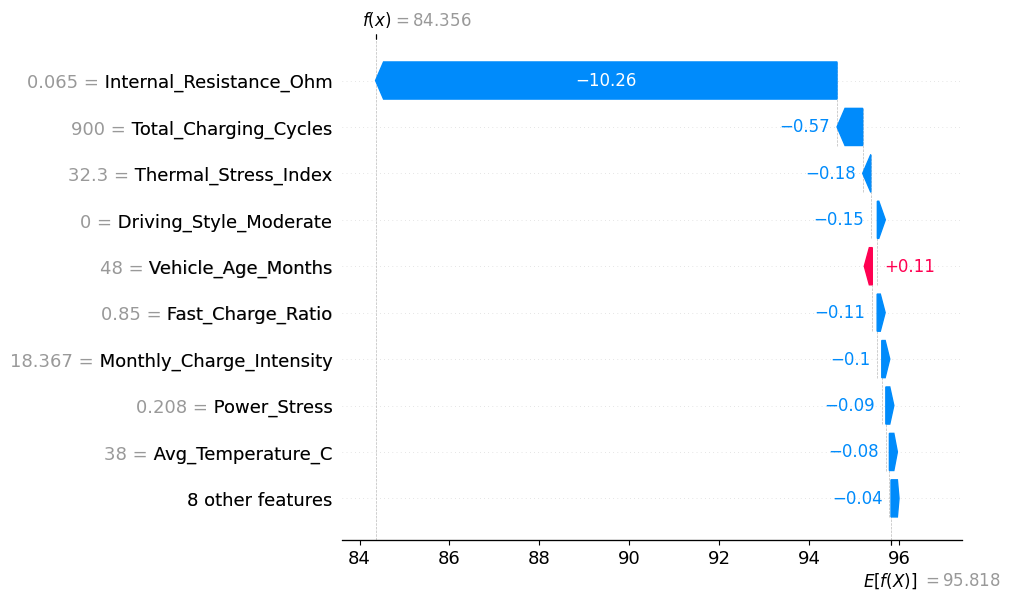

In [11]:
# --- 1. USER INPUTS (Change these values to test different scenarios) ---
capacity = 75.0
age_months = 48
charge_cycles = 900
temperature = 38.0
fast_charge = 0.85
discharge_rate = 3.2
internal_res = 0.0650

# Categorical Inputs (Brand, Battery Type, Driving Style)
is_ford = 0
is_hyundai = 0
is_tesla = 1
is_wuling = 0
is_nmc_battery = 1
is_conservative_driver = 0
is_moderate_driver = 0

# --- 2. BUILD DATAFRAME & CALCULATE ENGINEERING FEATURES ---
dummy_car = pd.DataFrame([{
    'Battery_Capacity_kWh': capacity, 'Vehicle_Age_Months': age_months,
    'Total_Charging_Cycles': charge_cycles, 'Avg_Temperature_C': temperature,
    'Fast_Charge_Ratio': fast_charge, 'Avg_Discharge_Rate_C': discharge_rate,
    'Internal_Resistance_Ohm': internal_res, 'Car_Model_Ford Mustang Mach-E': is_ford,
    'Car_Model_Hyundai Ioniq 5': is_hyundai, 'Car_Model_Tesla Model 3': is_tesla,
    'Car_Model_Wuling Air EV': is_wuling, 'Battery_Type_NMC': is_nmc_battery,
    'Driving_Style_Conservative': is_conservative_driver, 'Driving_Style_Moderate': is_moderate_driver
}])

# Auto-calculate the 3 smart features
dummy_car['Thermal_Stress_Index'] = dummy_car['Avg_Temperature_C'] * dummy_car['Fast_Charge_Ratio']
dummy_car['Monthly_Charge_Intensity'] = dummy_car['Total_Charging_Cycles'] / (dummy_car['Vehicle_Age_Months'] + 1)
dummy_car['Power_Stress'] = dummy_car['Avg_Discharge_Rate_C'] * dummy_car['Internal_Resistance_Ohm']

# --- 3. INSTANT INFERENCE & EXPLANATION ---
xgb_prediction = xgb_model.predict(dummy_car)[0]

print("==================================================")
print(f"🔋 PREDICTED BATTERY HEALTH (SoH): {xgb_prediction:.2f} %")
print("==================================================")

# Generate XGBoost Waterfall Plot instantly
print("\nGenerating SHAP Explanation...")
shap_values_single = explainer_xgb(dummy_car)
shap.plots.waterfall(shap_values_single[0])

In [ ]:
# Aşağı kısım model eğitimi, üst kısım eğitilmiş modeli kullanma.

In [1]:
# Install SHAP silently if it's not already installed
!pip install shap -q

import pandas as pd
import numpy as np
import shap
import joblib
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

print("All systems go! Initializing Volt-Guardian XAI...")

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Load the dataset
# IMPORTANT: Make sure this path is correct for your shared drive folder
file_path = '/content/drive/MyDrive/Volt-Guardian/ev_battery_degradation_v1.csv'
df = pd.read_csv(file_path)

print("Data loaded successfully. Here are the first 5 rows:")
display(df.head())

All systems go! Initializing Volt-Guardian XAI...
Mounted at /content/drive
Data loaded successfully. Here are the first 5 rows:


,Vehicle_ID,Car_Model,Battery_Type,Battery_Capacity_kWh,Vehicle_Age_Months,Total_Charging_Cycles,Avg_Temperature_C,Fast_Charge_Ratio,Avg_Discharge_Rate_C,Driving_Style,Internal_Resistance_Ohm,SoH_Percent,Battery_Status
0,1fb46ae8,Tesla Model 3,NMC,75.0,41,390,21.5,0.51,2.22,Aggressive,0.0362,94.60,Healthy
1,b7ef35aa,Tesla Model 3,NMC,75.0,29,401,18.0,0.62,1.34,Aggressive,0.0333,95.68,Healthy
2,76cb49e0,Ford Mustang Mach-E,NMC,88.0,71,941,18.4,0.78,1.48,Conservative,0.0526,89.80,Healthy
3,456a7aef,Ford Mustang Mach-E,NMC,88.0,57,378,10.8,0.61,0.72,Moderate,0.0314,96.29,Healthy
4,bd758049,Tesla Model 3,NMC,75.0,58,239,30.3,0.89,1.48,Conservative,0.0297,96.75,Healthy


In [2]:
# 1. Drop the useless ID column
df_clean = df.drop(columns=['Vehicle_ID'])

# 2. Convert text columns (object) to binary (0 and 1)
df_processed = pd.get_dummies(df_clean, columns=['Car_Model', 'Battery_Type', 'Driving_Style'], drop_first=True)

# 3. FEATURE ENGINEERING (Creating new smart columns)
df_processed['Thermal_Stress_Index'] = df_processed['Avg_Temperature_C'] * df_processed['Fast_Charge_Ratio']
df_processed['Monthly_Charge_Intensity'] = df_processed['Total_Charging_Cycles'] / (df_processed['Vehicle_Age_Months'] + 1)
df_processed['Power_Stress'] = df_processed['Avg_Discharge_Rate_C'] * df_processed['Internal_Resistance_Ohm']

# 4. Define Target (y) and Inputs (X)
y = df_processed['SoH_Percent']
X = df_processed.drop(columns=['SoH_Percent', 'Battery_Status'])

print(f"Data preprocessing complete! The model will use {X.shape[1]} input features.")

Data preprocessing complete! The model will use 17 input features.


In [3]:
# Split the data into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training the Random Forest model... Please wait.")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Training Completed! 🎉\n")

# Evaluation
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
std_dev = (y_test - predictions).std()

print("--- MODEL EVALUATION METRICS ---")
print(f"Mean Absolute Error (MAE) : % {mae:.2f}")
print(f"Error Standard Deviation  : % {std_dev:.2f}")
print(f"R-Squared (R2 Score)      : % {r2*100:.2f}")

Training the Random Forest model... Please wait.
Training Completed! 🎉

--- MODEL EVALUATION METRICS ---
Mean Absolute Error (MAE) : % 0.29
Error Standard Deviation  : % 0.38
R-Squared (R2 Score)      : % 98.66


In [7]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score

# (X_train, X_test etc. are already defined from your previous split)

print("Training the XGBoost model... Please wait.")
# We use XGBRegressor instead of RandomForestRegressor.
# learning_rate is a special power of XGBoost (how fast it learns from mistakes)
model_xgb = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model_xgb.fit(X_train, y_train)
print("Training Completed! 🎉\n")

# Evaluation
predictions_xgb = model_xgb.predict(X_test)
mae_xgb = mean_absolute_error(y_test, predictions_xgb)
r2_xgb = r2_score(y_test, predictions_xgb)
std_dev_xgb = (y_test - predictions_xgb).std()

print("--- XGBOOST EVALUATION METRICS ---")
print(f"Mean Absolute Error (MAE) : % {mae_xgb:.2f}")
print(f"Error Standard Deviation  : % {std_dev_xgb:.2f}")
print(f"R-Squared (R2 Score)      : % {r2_xgb*100:.2f}")

Training the XGBoost model... Please wait.
Training Completed! 🎉

--- XGBOOST EVALUATION METRICS ---
Mean Absolute Error (MAE) : % 0.28
Error Standard Deviation  : % 0.35
R-Squared (R2 Score)      : % 98.83


In [8]:
import joblib

# XGBoost modelini kaydediyoruz
xgb_kayit_yolu = '/content/drive/MyDrive/Volt-Guardian/xgb_model.joblib'
joblib.dump(model_xgb, xgb_kayit_yolu)

print(f"👑 Yeni Kral (XGBoost) başarıyla kaydedildi: {xgb_kayit_yolu}")

👑 Yeni Kral (XGBoost) başarıyla kaydedildi: /content/drive/MyDrive/Volt-Guardian/xgb_model.joblib


In [4]:
# Save the model to your shared Drive
save_path = '/content/drive/MyDrive/Volt-Guardian/volt_guardian_model.joblib'
joblib.dump(model, save_path)

print(f"Model successfully serialized and saved to: {save_path}")

Model successfully serialized and saved to: /content/drive/MyDrive/Volt-Guardian/volt_guardian_model.joblib


Calculating SHAP values to explain model decisions... (This might take a minute)


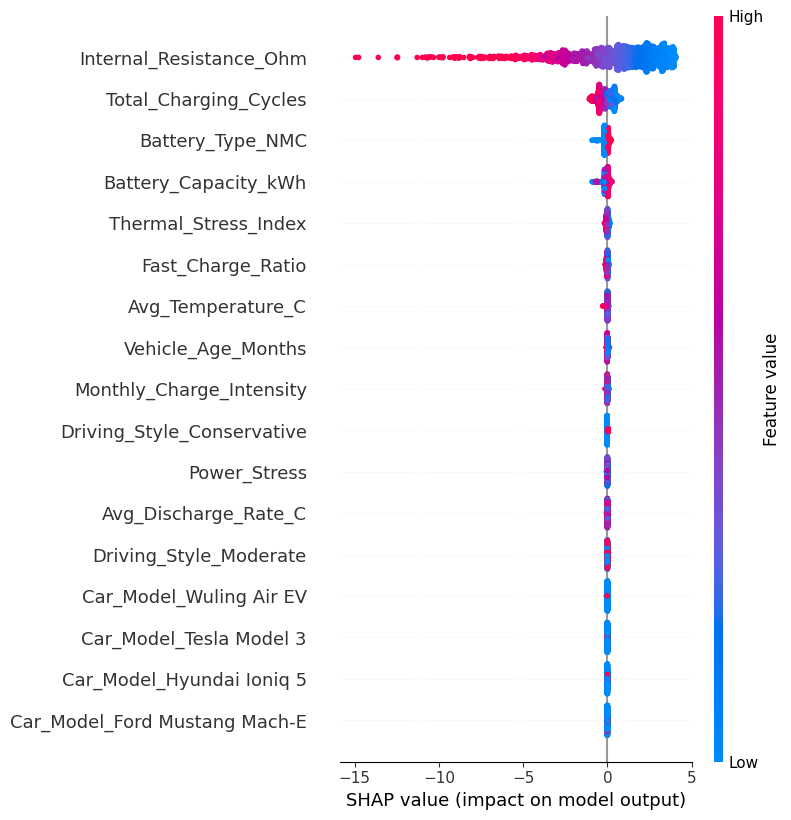

In [5]:
print("Calculating SHAP values to explain model decisions... (This might take a minute)")

# Create the explainer and calculate SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Plot the summary
shap.summary_plot(shap_values, X_test)

In [6]:
import joblib

print("Saving the heavy SHAP calculations to Google Drive...")

# Define paths for the explainer and the calculated values
explainer_path = '/content/drive/MyDrive/Volt-Guardian/shap_explainer.joblib'
values_path = '/content/drive/MyDrive/Volt-Guardian/shap_values.joblib'

# Save (Serialize) both objects
joblib.dump(explainer, explainer_path)
joblib.dump(shap_values, values_path)

print("SUCCESS! SHAP values are frozen and saved. You will never wait 10 minutes again. 🎉")

Saving the heavy SHAP calculations to Google Drive...
SUCCESS! SHAP values are frozen and saved. You will never wait 10 minutes again. 🎉


In [12]:
import shap
import joblib

print("Generating and saving the SHAP brain for XGBoost... (This might take a moment)")

# Create the new explainer for the XGBoost model
explainer_xgb = shap.TreeExplainer(model_xgb)

# Save the new explainer directly to Drive (Added 'xgb_' prefix to avoid overwriting the Random Forest one)
joblib.dump(explainer_xgb, '/content/drive/MyDrive/Volt-Guardian/shap_explainer_xgb.joblib')

print("✅ XGBoost SHAP brain successfully frozen and saved! You are completely ready for deployment.")

Generating and saving the SHAP brain for XGBoost... (This might take a moment)
✅ XGBoost SHAP brain successfully frozen and saved! You are completely ready for deployment.
